# Machine Learning Capstone - Review 1
## Corporate Credit Rating with Financial Ratios

**Tracks covered:** Regression and Classification Part A

**Goal:** Predict a credit rating score using financial ratios and classify companies into the given binary rating classes.

## 1. Problem Statement

Businesses generate large amounts of financial data across profitability, liquidity, leverage, cash flow, and operational performance. However, evaluating a company’s overall financial health and creditworthiness from these diverse indicators is complex and often relies on manual analysis. This project aims to develop a Machine Learning-based Business Financial Health & Credit Intelligence Platform that analyzes corporate financial indicators and business attributes to assess financial performance, classify credit risk, and identify distinct financial health profiles among companies.

- **Regression:** Predict the ordered credit rating score.
- **Classification:** Predict the given binary rating class.
- **Clustering:** Which companies have similar financial characteristics?

The models are compared using common test data so that their performance can be compared fairly.

## 2. Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

## 3. Load the Dataset

In [28]:
df = pd.read_csv("../data/corporateCreditRatingWithFinancialRatios.csv")

print("Shape:", df.shape)
df.head()

Shape: (7805, 25)


,Rating Agency,Corporation,Rating,Rating Date,CIK,Binary Rating,SIC Code,Sector,Ticker,Current Ratio,...,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,1056903,1,4941.0,Utils,AWR,1.1507,...,28.9834,13.6093,8.3224,0.3173,8.1724,8.1978,2.6385,4.4530,1.9957,-0.1333
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,8670,1,7374.0,BusEq,ADP,1.1129,...,23.9379,20.8699,13.5690,0.3324,22.0354,47.2858,4.4944,21.8765,0.2501,0.3132
2,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,8858,1,5065.0,Shops,AVT,1.9276,...,3.6338,3.0536,2.1418,2.4620,13.6376,16.7991,5.2731,9.6494,-7.6079,-7.3231
3,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,1035201,1,4941.0,Utils,CWT,0.8358,...,27.9377,15.1135,9.0246,0.2946,9.6412,9.7015,2.6583,5.1018,1.7438,-0.8999
4,Standard & Poor's Ratings Services,Cardinal Health Inc.,A,2010-07-14,721371,1,5122.0,Shops,CAH,1.2931,...,1.5847,1.2304,NaN,4.9276,11.1256,19.4184,2.9364,8.1844,1.9725,2.4174


## 4. Dataset Audit

In [31]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

Data Types:
Rating Agency                        str
Corporation                          str
Rating                               str
Rating Date                          str
CIK                                int64
Binary Rating                      int64
SIC Code                         float64
Sector                               str
Ticker                               str
Current Ratio                    float64
Long-term Debt / Capital         float64
Debt/Equity Ratio                float64
Gross Margin                     float64
Operating Margin                 float64
EBIT Margin                      float64
EBITDA Margin                    float64
Pre-Tax Profit Margin            float64
Net Profit Margin                float64
Asset Turnover                   float64
ROE - Return On Equity           float64
Return On Tangible Equity        float64
ROA - Return On Assets           float64
ROI - Return On Investment       float64
Operating Cash Flow Per Share    float64
Free

### Observation

The dataset contains **7,805 rows and 25 columns**. There are no missing values and no duplicate rows, so no row needs to be removed for these two reasons.

## 5. Target Distribution

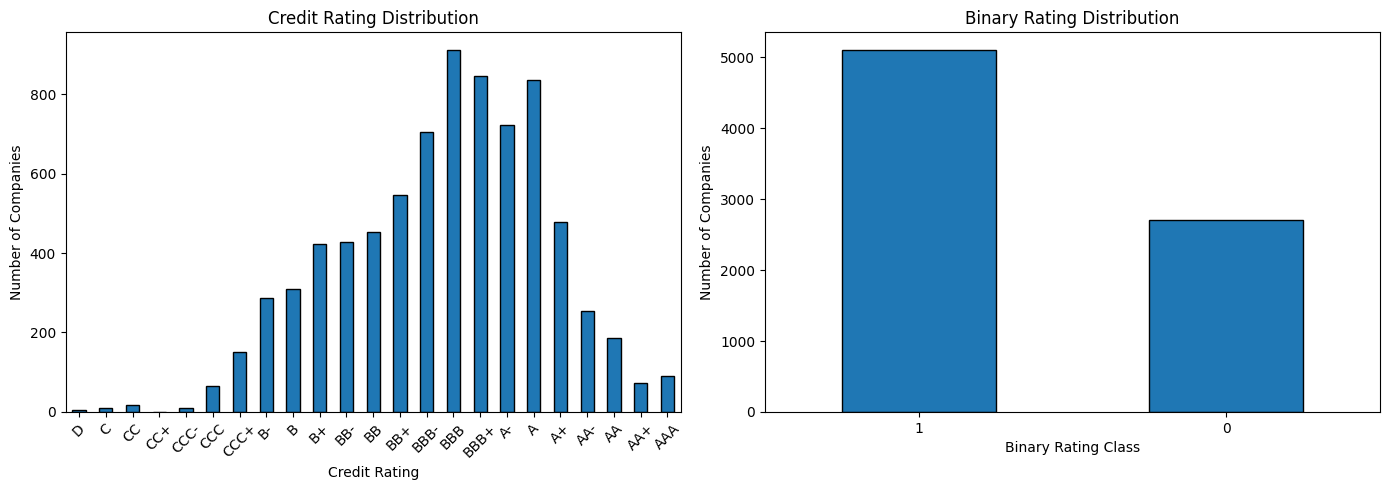

Binary Rating Distribution:
Binary Rating
1    5099
0    2706
Name: count, dtype: int64


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_order = [
    'D', 'C', 'CC', 'CC+', 'CCC-', 'CCC', 'CCC+',
    'B-', 'B', 'B+', 'BB-', 'BB', 'BB+',
    'BBB-', 'BBB', 'BBB+', 'A-', 'A', 'A+',
    'AA-', 'AA', 'AA+', 'AAA'
]
rating_counts = df['Rating'].value_counts().reindex(rating_order, fill_value=0)
rating_counts.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Credit Rating Distribution')
axes[0].set_xlabel('Credit Rating')
axes[0].set_ylabel('Number of Companies')
axes[0].tick_params(axis='x', rotation=45)

df['Binary Rating'].value_counts().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Binary Rating Distribution')
axes[1].set_xlabel('Binary Rating Class')
axes[1].set_ylabel('Number of Companies')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Binary Rating Distribution:")
print(df['Binary Rating'].value_counts())

### Observation

The target variables are imbalanced. The credit rating distribution is somewhat bell-shaped but heavily concentrated in the middle investment-grade and speculative-grade tiers (e.g., BBB, BB), while extreme ratings (like AAA or D) are rare. The `Binary Rating` class is also imbalanced, meaning stratified splitting is necessary for robust classification training.

## 6. Feature Distribution

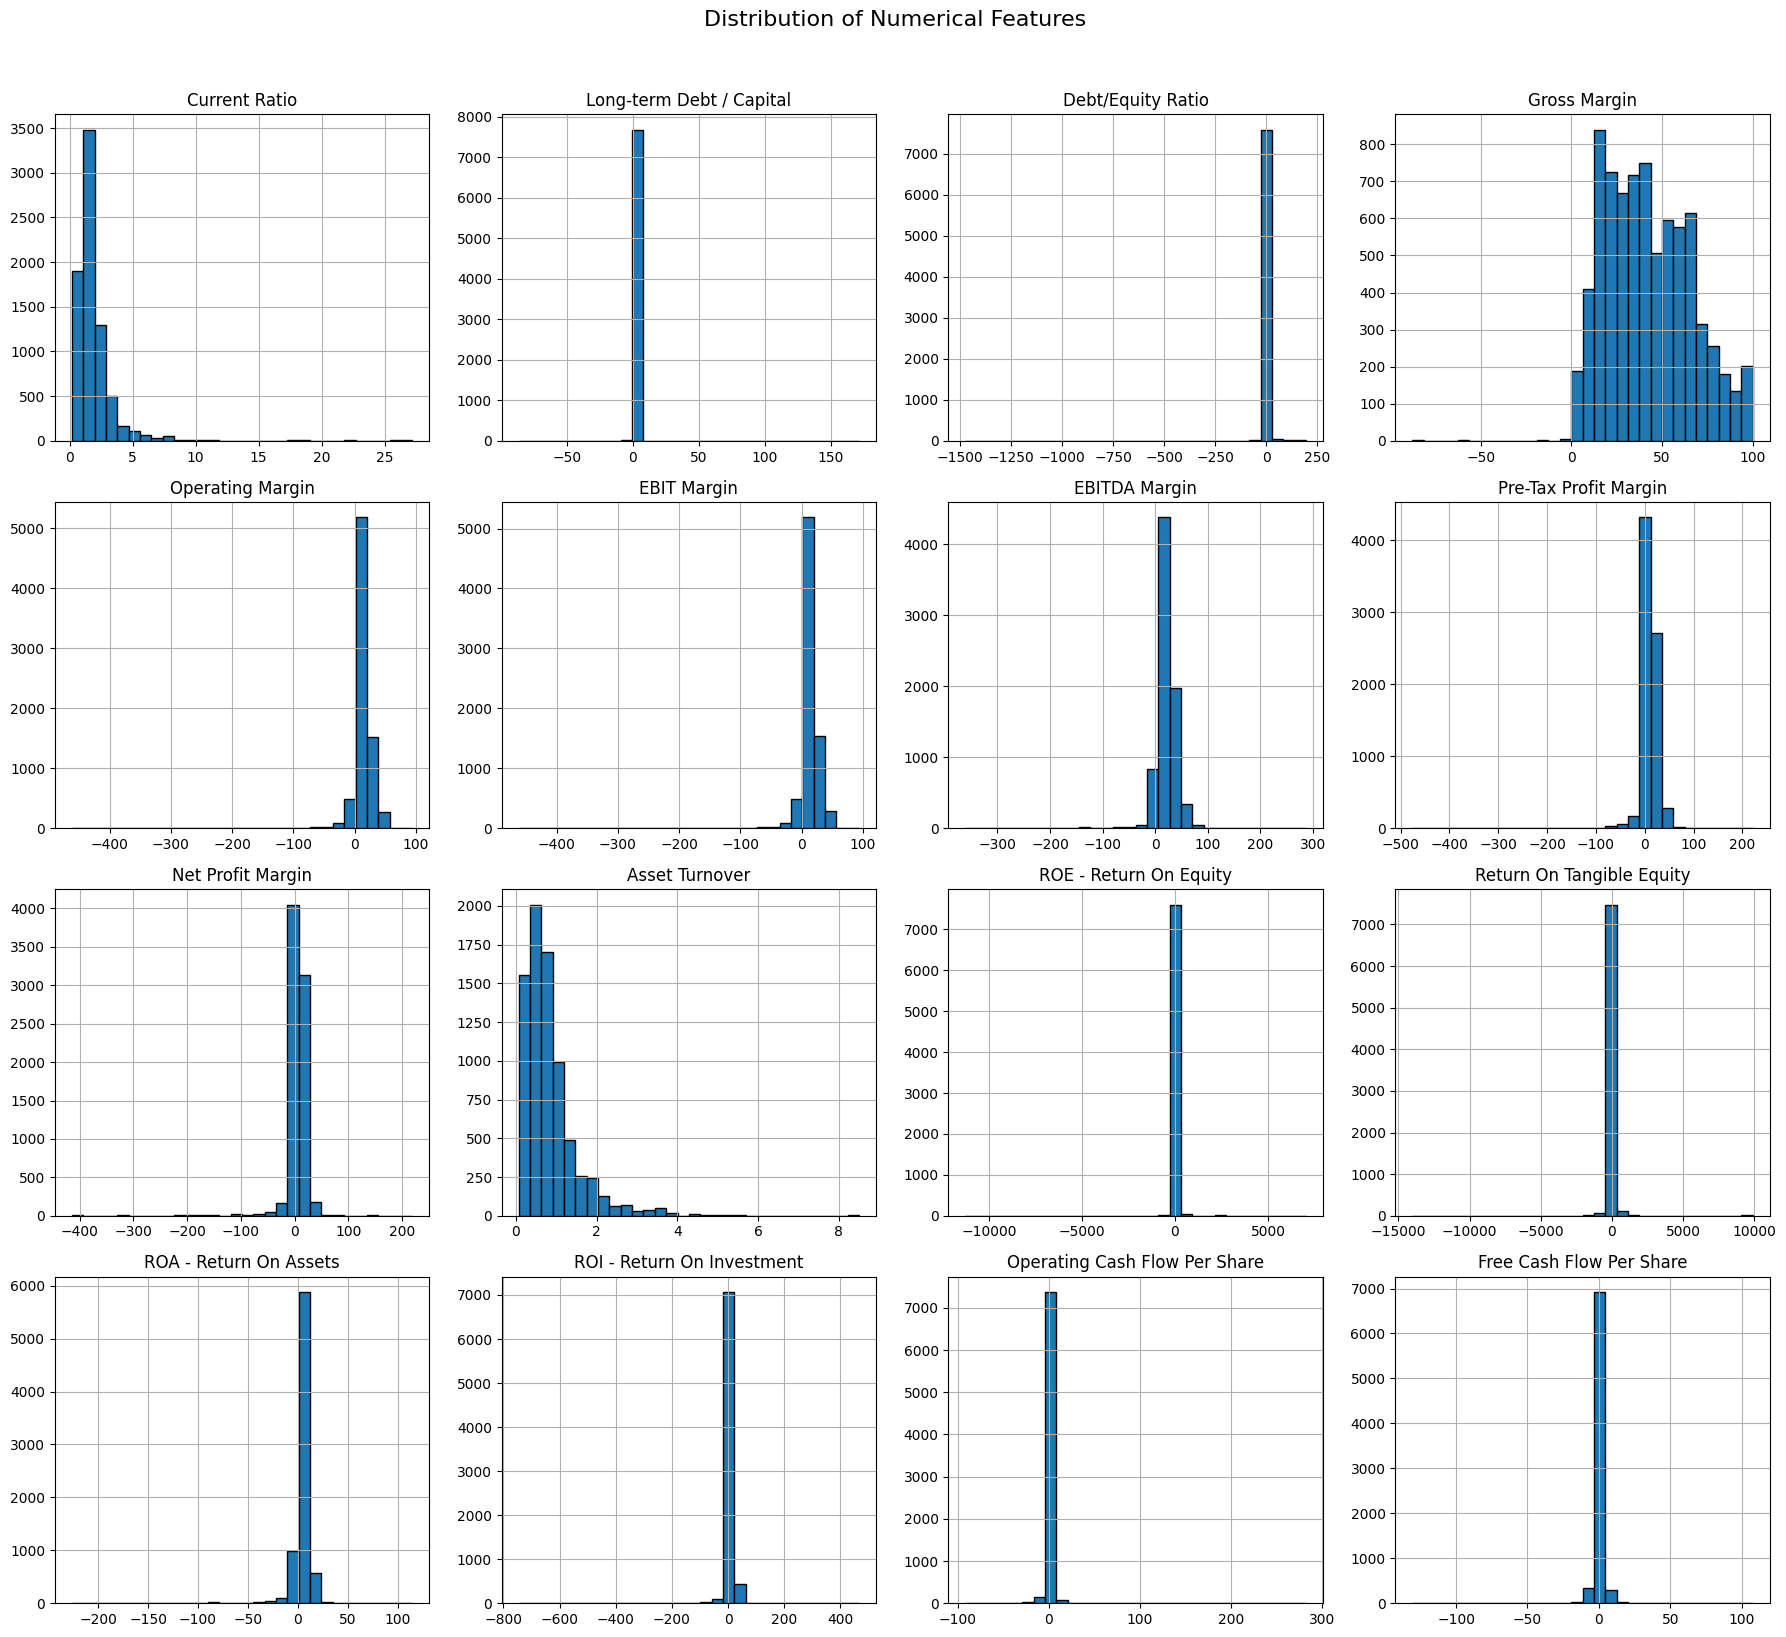

In [33]:
# Drop high-cardinality identifiers and non-meaningful numerical features for distribution plots
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in ['CIK', 'SIC Code', 'Binary Rating']:
    if col in num_cols:
        num_cols.remove(col)

df[num_cols].hist(figsize=(18, 16), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

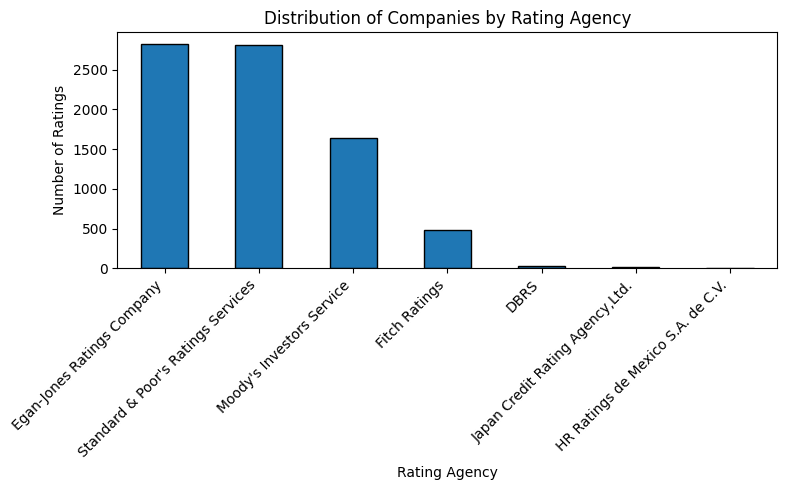

In [34]:
plt.figure(figsize=(8, 5))
df['Rating Agency'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Distribution of Companies by Rating Agency')
plt.xlabel('Rating Agency')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation

The numerical financial ratios have vastly different ranges, with several features (like Debt/Equity Ratio and Cash Flow Per Share) showing extreme skewness and long tails. This confirms the necessity of using a scaler (like StandardScaler) before distance-based or linear modeling.

*Note on Identifiers*: High-cardinality categorical fields such as `Corporation` and `Ticker` (and identifiers like `CIK`) have too many unique values to plot meaningfully, so their distribution plots are omitted.

## 7. Sector Distribution

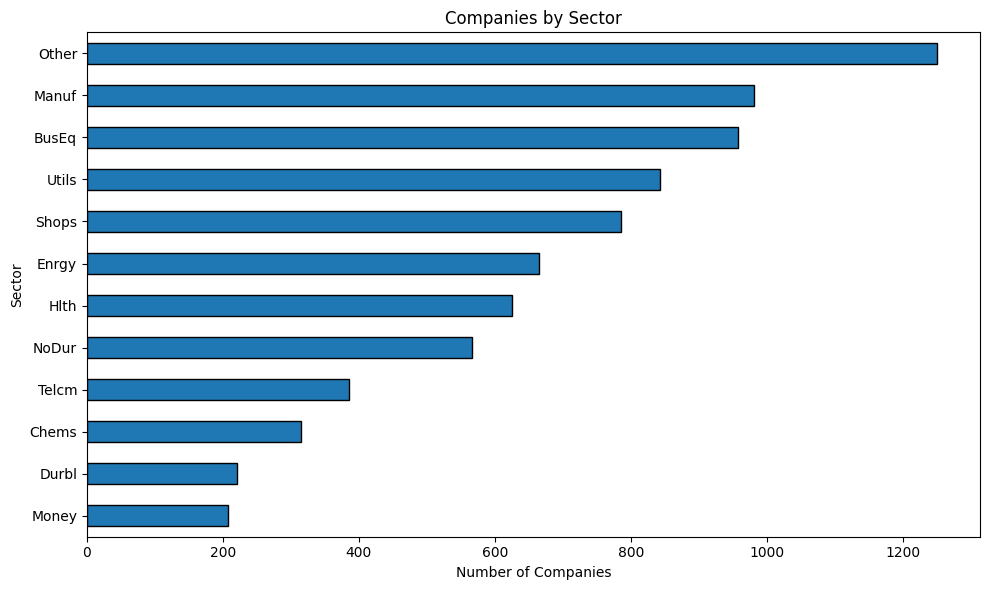

In [35]:
sector_counts = df['Sector'].value_counts()

plt.figure(figsize=(10, 6))
sector_counts.sort_values().plot(kind='barh', edgecolor='black')
plt.title('Companies by Sector')
plt.xlabel('Number of Companies')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

### Observation

The dataset spans a variety of sectors, but some sectors dominate the data more than others (e.g., typical corporate sectors have significantly more companies rated). Since Sector is categorical, it must be one-hot encoded to avoid imposing a false numerical order before model training.

## 8. Correlation Heatmap

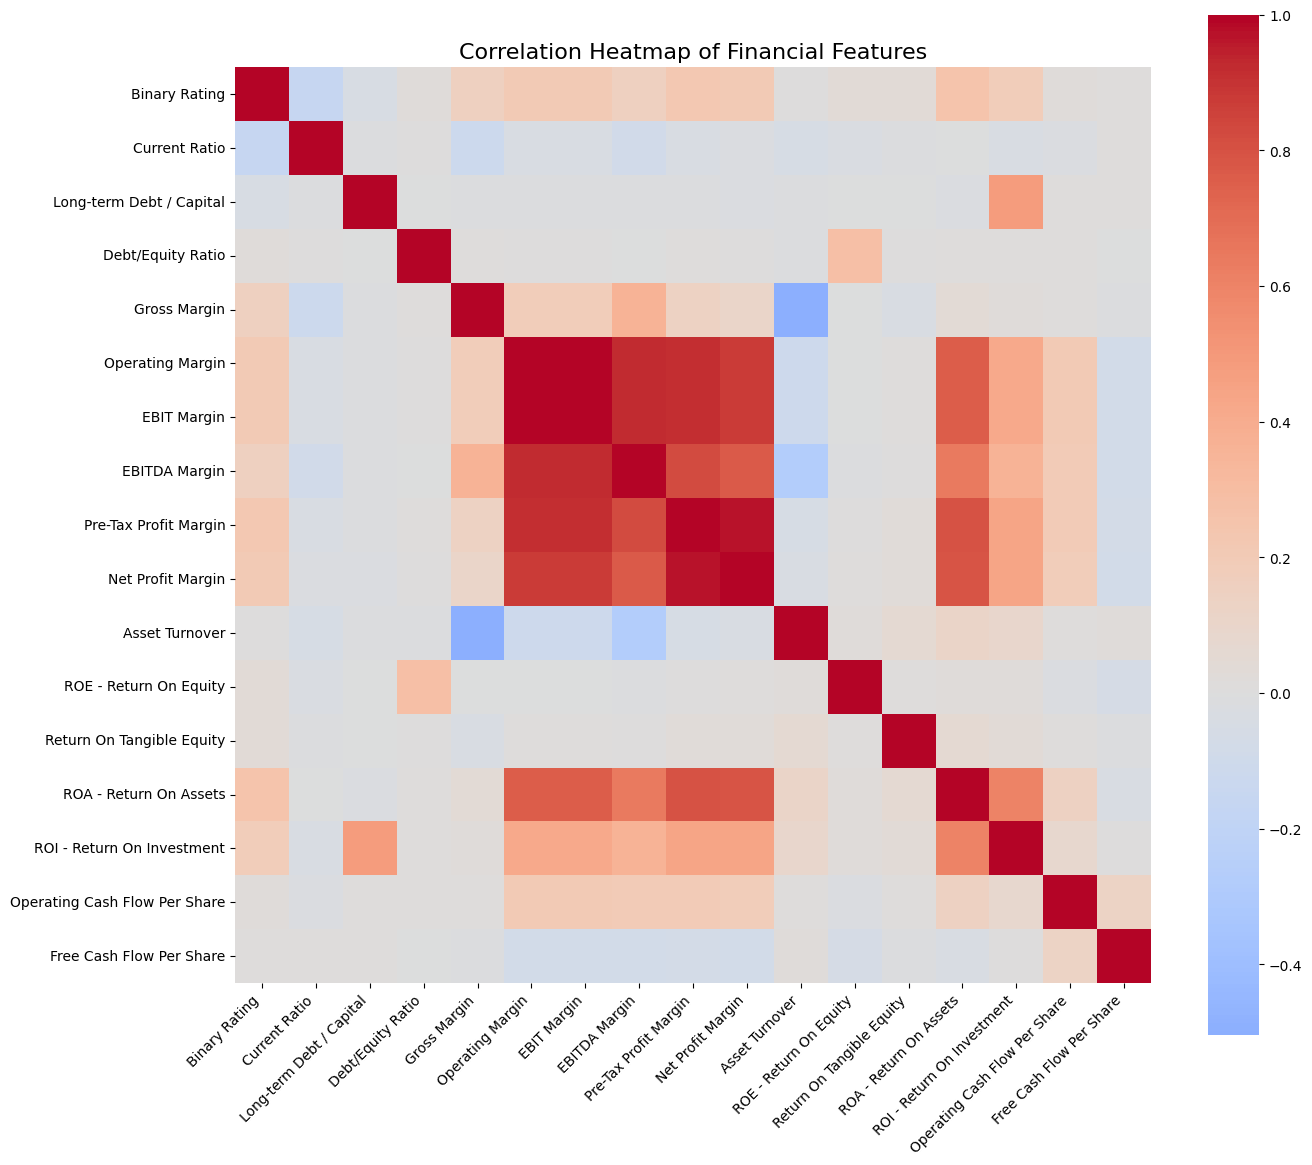

In [36]:
corr_cols = [
    'Binary Rating',
    'Current Ratio',
    'Long-term Debt / Capital',
    'Debt/Equity Ratio',
    'Gross Margin',
    'Operating Margin',
    'EBIT Margin',
    'EBITDA Margin',
    'Pre-Tax Profit Margin',
    'Net Profit Margin',
    'Asset Turnover',
    'ROE - Return On Equity',
    'Return On Tangible Equity',
    'ROA - Return On Assets',
    'ROI - Return On Investment',
    'Operating Cash Flow Per Share',
    'Free Cash Flow Per Share'
]

plt.figure(figsize=(14, 12))
sns.heatmap(df[corr_cols].corr(), cmap='coolwarm', center=0, annot=False, fmt=".2f", square=True)
plt.title('Correlation Heatmap of Financial Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The heatmap reveals strong positive correlations among the various profit margin metrics (e.g., Gross Margin, Operating Margin, EBIT Margin), which is expected as they measure overlapping aspects of profitability. Additionally, profitability metrics and returns (like ROA and ROI) exhibit noticeable positive relationships with the `Binary Rating`. This indicates that more profitable companies tend to have better credit ratings. To reduce multicollinearity among profit margins, feature engineering (like computing an Average Profit Margin) can be useful.

## 9. Feature vs Rating Scatter Plots

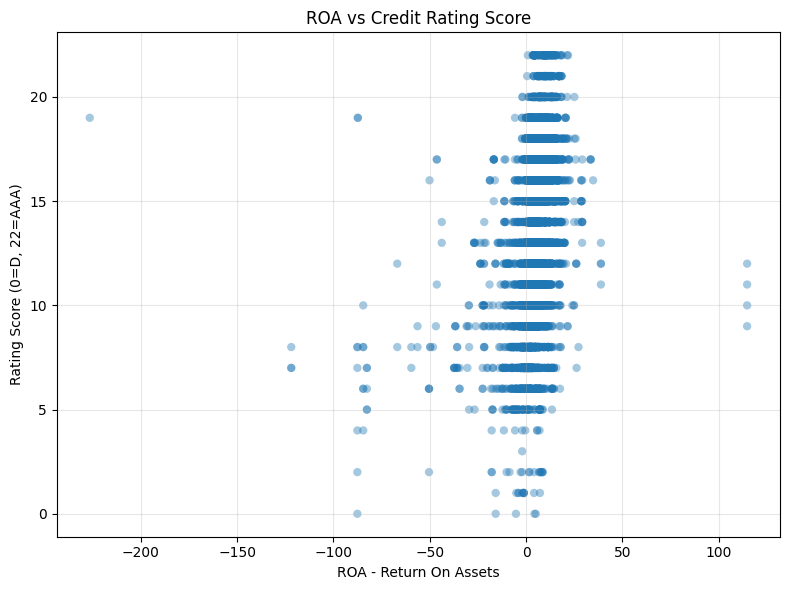

In [37]:
rating_map = {
    'AAA': 22, 'AA+': 21, 'AA': 20, 'AA-': 19,
    'A+': 18, 'A': 17, 'A-': 16,
    'BBB+': 15, 'BBB': 14, 'BBB-': 13,
    'BB+': 12, 'BB': 11, 'BB-': 10,
    'B+': 9, 'B': 8, 'B-': 7,
    'CCC+': 6, 'CCC': 5, 'CCC-': 4,
    'CC+': 3, 'CC': 2, 'C': 1, 'D': 0
}

df['Rating_Score'] = df['Rating'].map(rating_map)

plt.figure(figsize=(8, 6))
plt.scatter(df['ROA - Return On Assets'], df['Rating_Score'], alpha=0.4, edgecolors='none')
plt.title('ROA vs Credit Rating Score')
plt.xlabel('ROA - Return On Assets')
plt.ylabel('Rating Score (0=D, 22=AAA)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

There is a visible positive trend between ROA and Rating Score: companies with higher Returns on Assets are generally clustered towards higher credit rating scores. However, at lower ROA levels, there is significant variance in rating scores, indicating that while poor ROA is a risk factor, it alone does not perfectly determine creditworthiness.

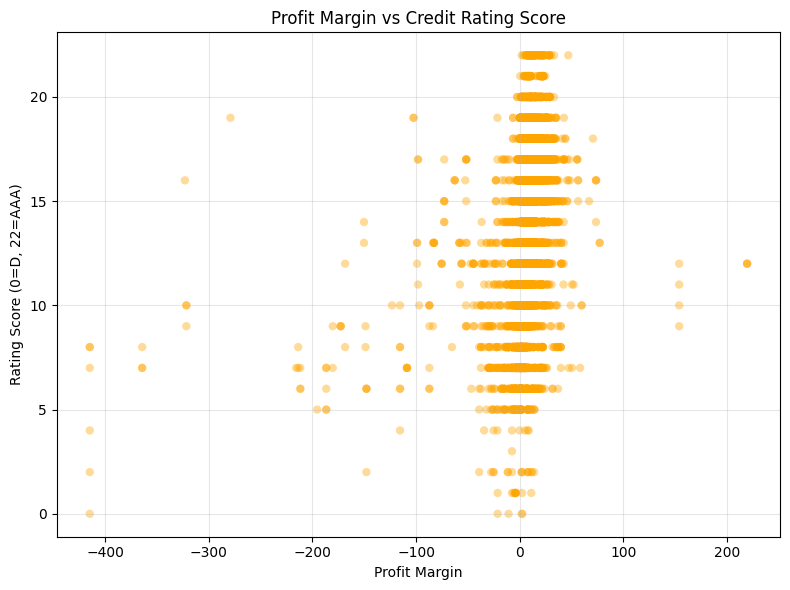

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Average Profit Margin'] if 'Average Profit Margin' in df.columns else df['Net Profit Margin'],
            df['Rating_Score'], alpha=0.4, edgecolors='none', color='orange')
plt.title('Profit Margin vs Credit Rating Score')
plt.xlabel('Profit Margin')
plt.ylabel('Rating Score (0=D, 22=AAA)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

Similar to ROA, Profit Margin exhibits a positive relationship with Rating Score. Companies with higher profit margins rarely receive the lowest credit ratings, but there is still considerable vertical spread in the data points. This supports the inclusion of profit-margin information in the regression models as a key indicator of credit health.

## 10. Feature Engineering

In [39]:
# Average of the main profit margin measures
profit_cols = [
    'Gross Margin',
    'Operating Margin',
    'EBIT Margin',
    'EBITDA Margin',
    'Pre-Tax Profit Margin',
    'Net Profit Margin'
]

df['Average Profit Margin'] = df[profit_cols].mean(axis=1)

print(df[['Average Profit Margin']].head())

   Average Profit Margin
0              27.917650
1              23.617350
2               4.560767
3              25.582533
4               1.861480


### Why this feature?

The six margin features measure different levels of profitability. Their average gives one overall profitability measure and may help the models capture the company's general profit strength.

## 10.1 Outlier Check

In [40]:
# Count IQR outliers in numerical model features
check_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in ['CIK', 'Binary Rating', 'Rating_Score']
]

outlier_counts = {}

for col in check_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_table = pd.Series(outlier_counts, name='Outlier Count')
outlier_table.sort_values(ascending=False).head(10)

Return On Tangible Equity        1157
Debt/Equity Ratio                 976
ROE - Return On Equity            971
Free Cash Flow Per Share          937
Operating Cash Flow Per Share     878
Net Profit Margin                 617
ROI - Return On Investment        575
Pre-Tax Profit Margin             559
ROA - Return On Assets            522
Current Ratio                     496
Name: Outlier Count, dtype: int64


### Observation

Several financial ratio features contain extreme values. These values are not removed as rows; instead, they are clipped using IQR limits calculated from the training data.


## 11. Prepare the Data

In [41]:
# Columns that identify the company or rating record
drop_cols = [
    'Rating Agency',
    'Corporation',
    'Rating',
    'Rating Date',
    'CIK',
    'Ticker'
]

model_df = df.drop(columns=drop_cols)

X = model_df.drop(columns=['Rating_Score', 'Binary Rating'])
y_reg = model_df['Rating_Score']
y_clf = model_df['Binary Rating']

print("Features before encoding:", X.shape[1])

Features before encoding: 19


## 12. Train-Test Split

In [42]:
# Same 80:20 split for regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Stratified split for classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Regression training rows:", X_train_r.shape[0])
print("Regression test rows:", X_test_r.shape[0])
print("Classification training rows:", X_train_c.shape[0])
print("Classification test rows:", X_test_c.shape[0])

Regression training rows: 6244
Regression test rows: 1561
Classification training rows: 6244
Classification test rows: 1561


## 13. Encode and Treat Outliers

In [43]:
from sklearn.impute import SimpleImputer

def clip_outliers(train, test):
    train = train.copy()
    test = test.copy()

    for col in train.columns:
        q1 = train[col].quantile(0.25)
        q3 = train[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        train[col] = train[col].clip(lower, upper)
        test[col] = test[col].clip(lower, upper)

    return train, test


# Convert Sector into dummy variables.
X_train_r = pd.get_dummies(X_train_r, columns=['Sector'], drop_first=True, dtype=int)
X_test_r = pd.get_dummies(X_test_r, columns=['Sector'], drop_first=True, dtype=int)

X_train_r, X_test_r = X_train_r.align(
    X_test_r, join='left', axis=1, fill_value=0
)

X_train_c = pd.get_dummies(X_train_c, columns=['Sector'], drop_first=True, dtype=int)
X_test_c = pd.get_dummies(X_test_c, columns=['Sector'], drop_first=True, dtype=int)

X_train_c, X_test_c = X_train_c.align(
    X_test_c, join='left', axis=1, fill_value=0
)


# Handle missing values using median imputation.
# Imputer is fitted only on the training data.
imputer_r = SimpleImputer(strategy='median')

X_train_r = pd.DataFrame(
    imputer_r.fit_transform(X_train_r),
    columns=X_train_r.columns,
    index=X_train_r.index
)

X_test_r = pd.DataFrame(
    imputer_r.transform(X_test_r),
    columns=X_test_r.columns,
    index=X_test_r.index
)


imputer_c = SimpleImputer(strategy='median')

X_train_c = pd.DataFrame(
    imputer_c.fit_transform(X_train_c),
    columns=X_train_c.columns,
    index=X_train_c.index
)

X_test_c = pd.DataFrame(
    imputer_c.transform(X_test_c),
    columns=X_test_c.columns,
    index=X_test_c.index
)


# Clip extreme values using only training-set limits.
X_train_r, X_test_r = clip_outliers(X_train_r, X_test_r)
X_train_c, X_test_c = clip_outliers(X_train_c, X_test_c)


print("Final regression features:", X_train_r.shape[1])
print("Final Classification features:", X_train_c.shape[1])
print("Missing values after imputation:")
print("Regression:", X_train_r.isnull().sum().sum())
print("Classification:", X_train_c.isnull().sum().sum())

Final regression features: 29
Final Classification features: 29
Missing values after imputation:
Regression: 0
Classification: 0


### Observation

There were no missing values or duplicate rows. Extreme numerical values are clipped using IQR limits calculated from the training data. Sector is one-hot encoded so that it is not treated as an ordered number.

## 14. Feature Scaling

In [44]:
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print("Scaling completed.")

Scaling completed.


### Why scaling?

Scaling puts the features on a similar range. It is especially important for Ridge, Lasso, ElasticNet, SVR and KNN.

## 15. Save Preprocessed Datasets

Save the cleaned, engineered, encoded, and scaled splits for the Regression and Classification tracks to `data/` so that modeling notebooks (`regression.ipynb` and `classification.ipynb`) can use them directly.

In [45]:
import os

data_dir = '../data' if os.path.exists('../data') else 'data'
os.makedirs(data_dir, exist_ok=True)

# 1. Regression datasets
train_reg = pd.DataFrame(X_train_r_scaled, columns=X_train_r.columns)
train_reg['Rating_Score'] = y_train_r.values

test_reg = pd.DataFrame(X_test_r_scaled, columns=X_test_r.columns)
test_reg['Rating_Score'] = y_test_r.values

train_reg.to_csv(os.path.join(data_dir, 'train_regression_preprocessed.csv'), index=False)
test_reg.to_csv(os.path.join(data_dir, 'test_regression_preprocessed.csv'), index=False)

# 2. Classification datasets
train_clf = pd.DataFrame(X_train_c_scaled, columns=X_train_c.columns)
train_clf['Binary Rating'] = y_train_c.values

test_clf = pd.DataFrame(X_test_c_scaled, columns=X_test_c.columns)
test_clf['Binary Rating'] = y_test_c.values

train_clf.to_csv(os.path.join(data_dir, 'train_classification_preprocessed.csv'), index=False)
test_clf.to_csv(os.path.join(data_dir, 'test_classification_preprocessed.csv'), index=False)

print('Preprocessed datasets successfully saved to:', data_dir)
print(f'  - Regression: train {train_reg.shape}, test {test_reg.shape}')
print(f'  - Classification: train {train_clf.shape}, test {test_clf.shape}')

Preprocessed datasets successfully saved to: ../data
  - Regression: train (6244, 30), test (1561, 30)
  - Classification: train (6244, 30), test (1561, 30)
